In [ ]:
import pandas as pd

def load_txt_dataset(file_path):
    texts, labels = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if ';' in line:
                text, label = line.rsplit(';', 1)
                texts.append(text)
                labels.append(label)
    return pd.DataFrame({'text': texts, 'label': labels})


In [ ]:
import zipfile
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()

# Get uploaded filename automatically
archive_path = list(uploaded.keys())[0]

# Extract zip
with zipfile.ZipFile(archive_path, 'r') as zip_ref:
    zip_ref.extractall('unzipped_archive')

# Check extracted files
import os
print(os.listdir('unzipped_archive'))

# Load dataset
file_path = 'unzipped_archive/train.txt'
data = pd.read_csv(file_path, sep='\t', header=None, names=['label', 'text'])

print("Rows loaded:", len(data))
print(data.head())


Saving emotion.zip to emotion.zip
['val.txt', 'test.txt', 'train.txt']
Rows loaded: 16000
                                               label  text
0                    i didnt feel humiliated;sadness   NaN
1  i can go from feeling so hopeless to so damned...   NaN
2  im grabbing a minute to post i feel greedy wro...   NaN
3  i am ever feeling nostalgic about the fireplac...   NaN
4                         i am feeling grouchy;anger   NaN


In [ ]:
data = pd.read_csv(file_path, sep=';', header=None, names=['text','label'])


In [ ]:
data['label'] = data['label'].str.lower().str.strip()


In [ ]:
emotion_mapping = {
    'fear': 'anxiety',
    'sadness': 'stress',
    'anger': 'stress',
    'joy': 'positive',
    'love': 'positive',
    'surprise': 'neutral',
    'neutral': 'neutral'
}

data['label'] = data['label'].map(emotion_mapping)
data.dropna(inplace=True)

print("After mapping:")
print(data['label'].value_counts())


After mapping:
label
stress      6825
positive    6666
anxiety     1937
neutral      572
Name: count, dtype: int64


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

data['text'] = data['text'].apply(clean_text)


In [ ]:
from sklearn.model_selection import train_test_split

print("Before split class distribution:")
print(data['label'].value_counts())

# Remove very small classes (optional but safe)
counts = data['label'].value_counts()
valid_classes = counts[counts > 2].index
data = data[data['label'].isin(valid_classes)]

# Now define X and y AFTER filtering
X = data['text']
y = data['label']

print("Final dataset size:", len(data))
print("Final class distribution:")
print(y.value_counts())

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Before split class distribution:
label
stress      6825
positive    6666
anxiety     1937
neutral      572
Name: count, dtype: int64
Final dataset size: 16000
Final class distribution:
label
stress      6825
positive    6666
anxiety     1937
neutral      572
Name: count, dtype: int64
Train size: 12800
Test size: 3200


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes + TF-IDF Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes + TF-IDF Accuracy: 0.8746875
              precision    recall  f1-score   support

     anxiety       0.92      0.51      0.65       387
     neutral       1.00      0.11      0.20       115
    positive       0.89      0.96      0.92      1333
      stress       0.86      0.96      0.91      1365

    accuracy                           0.87      3200
   macro avg       0.92      0.63      0.67      3200
weighted avg       0.88      0.87      0.86      3200



In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    C=10,
    class_weight='balanced'
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM + TF-IDF Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM + TF-IDF Accuracy: 0.9303125
              precision    recall  f1-score   support

     anxiety       0.88      0.83      0.86       387
     neutral       0.74      0.86      0.80       115
    positive       0.95      0.96      0.95      1333
      stress       0.94      0.94      0.94      1365

    accuracy                           0.93      3200
   macro avg       0.88      0.90      0.89      3200
weighted avg       0.93      0.93      0.93      3200



In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression + TF-IDF Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression + TF-IDF Accuracy: 0.93
              precision    recall  f1-score   support

     anxiety       0.87      0.84      0.85       387
     neutral       0.68      0.91      0.78       115
    positive       0.95      0.95      0.95      1333
      stress       0.95      0.93      0.94      1365

    accuracy                           0.93      3200
   macro avg       0.86      0.91      0.88      3200
weighted avg       0.93      0.93      0.93      3200



In [ ]:
print("Model Comparison")

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Model Comparison
Naive Bayes Accuracy: 0.8746875
SVM Accuracy: 0.9303125
Logistic Regression Accuracy: 0.93


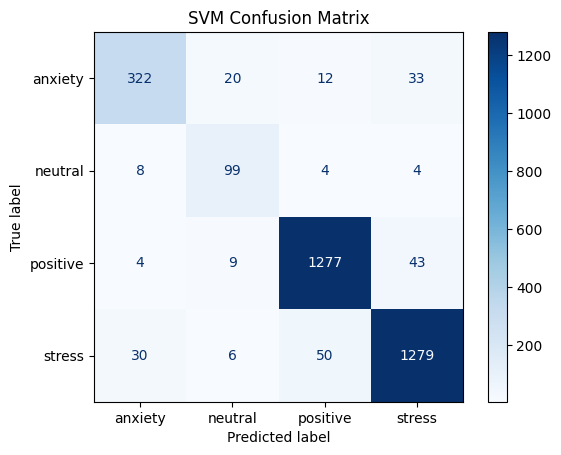

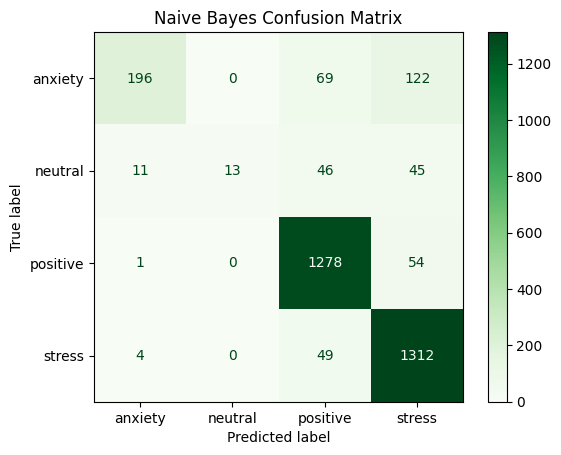

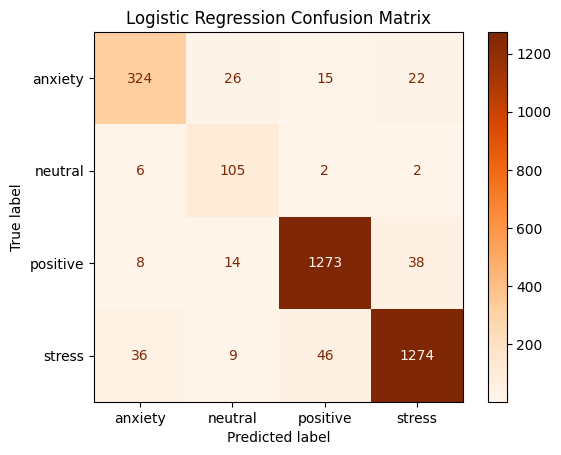

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -------- SVM --------
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()


# -------- Naive Bayes --------
cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp.plot(cmap="Greens")
plt.title("Naive Bayes Confusion Matrix")
plt.show()


# -------- Logistic Regression --------
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Oranges")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
def is_greeting(text):
    greetings = ["hi", "hello", "hey", "hai", "good morning", "good evening", ]
    return text.lower().strip() in greetings


In [ ]:
def is_too_short(text):
    return len(text.split()) < 3


In [ ]:
def predict_emotion(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])

    svm_pred = svm_model.predict(vector)[0]
    lr_pred = lr_model.predict(vector)[0]

    return svm_pred

In [ ]:
emotion_responses = {

    "anxiety": [
        "I sense exam anxiety. Take a slow, deep breath and focus on what you can control right now.",
        "Feeling anxious before exams is common. Try concentrating on one question or topic at a time.",
        "Anxiety can make thoughts race. Pausing and breathing slowly may help calm your mind.",
        "It seems like exam pressure is increasing. Ground yourself by reviewing familiar topics.",
        "Strong anxiety can affect focus. A short break or stretching may help reset your thoughts.",
        "Feeling anxious does not mean you are unprepared. Trust the effort you have already made.",
        "Exam anxiety often comes from overthinking outcomes. Focus on the process instead.",
        "You may be feeling nervous right now. Slow breathing can help stabilize your emotions.",
        "Anxiety can make exams feel overwhelming. Staying present can improve clarity.",
        "It sounds like worry is building up. Writing down key points may help organize your thoughts.",
        "High anxiety can reduce confidence. Remind yourself of your preparation and strengths.",
        "It’s okay to feel anxious before exams. Try grounding techniques like counting breaths.",
        "Exam-related anxiety shows that you care about performing well. Channel it into focus.",
        "You may be feeling tense. Relaxing your body can help calm your thoughts.",
        "Anxiety is temporary. Staying calm and steady can help you perform better."
    ],

    "stress": [
        "Exam stress often builds when tasks feel overwhelming. Breaking them into smaller steps can help.",
        "You seem stressed. Creating a simple study plan may reduce pressure.",
        "Academic stress is common during exams. Focus on one subject at a time.",
        "Stress can reduce concentration. Taking short breaks may improve productivity.",
        "It sounds like workload pressure is increasing. Prioritizing tasks can help.",
        "Exam stress can be managed by setting realistic goals for each study session.",
        "Feeling stressed may indicate mental fatigue. A short walk could help clear your mind.",
        "Stress during preparation is normal. Steady revision often works better than rushing.",
        "High stress can affect memory. Relaxation techniques may help restore focus.",
        "You may be feeling overloaded. Simplifying your study plan can reduce stress.",
        "Managing stress is important for exam success. Review key topics instead of everything.",
        "Stress can make learning harder. Slowing down may improve understanding.",
        "Exam stress increases with high expectations. Be patient with yourself.",
        "You appear mentally tired. Brief rest can help reduce stress.",
        "Stress is part of academic life. Organized study can make it manageable."
    ],

    "positive": [
        "That’s a great mindset! Confidence can strongly support exam performance.",
        "Feeling positive during preparation is a strong advantage. Keep going.",
        "Your positive attitude can help reduce exam anxiety and improve focus.",
        "It’s good to see this confidence. Consistent practice will reinforce it.",
        "Positive emotions can improve memory retention. Maintain this balance.",
        "A confident mindset supports better problem-solving during exams.",
        "Staying positive helps you approach exams calmly and clearly.",
        "Your motivation and optimism are valuable. Continue revising steadily.",
        "A positive outlook can help you stay resilient under exam pressure.",
        "Feeling confident suggests good preparation. Trust your effort."
    ],

    "neutral": [
        "You seem calm and balanced. This is a good time for focused revision.",
        "A neutral mindset can help improve concentration. Review key topics now.",
        "Staying calm supports effective learning. Structured study may help.",
        "This steady mindset is useful for exam preparation. Plan your next steps.",
        "A neutral emotional state can improve memory retention. Focus on important areas.",
        "You appear relaxed. This is a good moment for productive studying.",
        "Remaining calm helps reduce mistakes. Consider revising problem areas.",
        "A balanced mindset allows better understanding. Use this time wisely.",
        "Neutral emotions support focus. Review core concepts carefully.",
        "You seem composed. Organizing study materials may help now."
    ]
}


In [ ]:
import random

def chatbot_response(user_input):

    if is_greeting(user_input):
        return "Hello! I’m here to support you with exam-related concerns. How are you feeling today?"

    if is_too_short(user_input):
        return "Could you share a bit more about what you need help with?"

    # Detect study-related question
    study_keywords = ["how to study", "study tips", "how can i study", "revision", "prepare"]

    if any(keyword in user_input.lower() for keyword in study_keywords):
        return "A good study strategy includes setting small goals, revising actively, and practicing past questions. Would you like specific tips for a particular subject?"

    emotion = predict_emotion(user_input)

    exam_keywords = ["exam", "test", "study", "marks"]

    if not any(word in user_input.lower() for word in exam_keywords):
        return "I'm sorry you're feeling that way. Is this related to your exams or something else?"

    return random.choice(emotion_responses[emotion])



In [ ]:
print("Type 'exit' to stop")

while True:
    user_input = input("You: ")
    if user_input.lower() == 'exit':
        print("Chatbot: All the best!")
        break
    print("Chatbot:", chatbot_response(user_input))

Type 'exit' to stop
You: hi
Chatbot: Hello! I’m here to support you with exam-related concerns. How are you feeling today?
You: give me a exam centric positivity
Chatbot: Anxiety is temporary. Staying calm and steady can help you perform better.
You: give me a exam centric positivity
Chatbot: Anxiety can make exams feel overwhelming. Staying present can improve clarity.
You: give me a exam centric positivity
Chatbot: Strong anxiety can affect focus. A short break or stretching may help reset your thoughts.
You: exit
Chatbot: All the best!


In [ ]:
import joblib

joblib.dump(svm_model, "svm_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(lr_model, "logistic_model.pkl")
joblib.dump(nb_model, "nb_model.pkl")

['nb_model.pkl']

In [ ]:
from google.colab import files

files.download("svm_model.pkl")
files.download("logistic_model.pkl")
files.download("nb_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>